# IY021 – SimCLR Embeddings + SVM on ALL Experimental Data

**Goal:** Same analysis as `IY021_test_simclr_exp_data.ipynb` but including all experiments
with clear carbon-source labels from `EXP-25-IY008/4_transformed_exp_time_series/`.

**Environments (labels) — verified via `get_exp_summary`:**
- `0` — 2% glucose (experiments 19316, 18589, 19330)
- `1` — 0.1% glucose (experiments 19566, 18446, 19394)
- `2` — 0.01% glucose (experiments 19554, 20213)
- `3` — 2% galactose (experiment 19391 — pump: 2% raffinose → 2% galactose)
- `4` — 0.01% galactose (experiment 19392 — pump: 2% glucose → 0.01% galactose)

**Excluded experiments:**
- `18360` — no explicit carbon source concentration in filename ("2min" refers to interval)
- `18464` — mock condition (not a carbon source concentration)

**Length handling:** All series truncated to the global minimum timepoint count across
all loaded files. SimCLR models were trained on longer sequences so performance may differ
from the original notebook.

**Models evaluated (28 checkpoints):**
- IY017: instance-norm models, various batch sizes and d_model (D8, D16, D128)
- IY022: single-dataset models with global / joint / batch-wise normalisation
- IY023: mixed-dataset (all 4 sources) models with batch-wise normalisation

In [1]:
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm import tqdm

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
# sys.path.insert(0, str(Path("/home/ianyang/wela/src").resolve()))
from models.ssl_transformer import SSL_Transformer

np.random.seed(42)
torch.manual_seed(42)

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR  = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/4_transformed_exp_time_series")
EXP_DIR   = Path("/home/ianyang/stochastic_simulations/experiments")
META_COLS = ["id", "group", "experiment"]

print(f"Device: {DEVICE}")

Device: cuda


## 1. Load Experimental Data & Assign Labels

In [2]:
# Verify experimental conditions using get_exp_summary
import glob as _glob
from wela.get_exp_conditions import get_exp_summary

_BASE = "/home/ianyang/alibylite/high_quality_data_analysis"
_EXPERIMENT_OMIDS = {
    "19316": "19316_2020_10_26_steadystate_glucose_144m_2w2_00",
    "18589": "18589_2020_02_10_steadystate_glucose_898S_2w2_01",
    "19330": "19330_2020_11_02_steadystate_glucose_1345m_2w2_00",
    "19566": "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01",
    "18446": "18446_2020_01_08_steadystate_glucose_2w0p1_2min_01",
    "19394": "19394_2020_11_12_steadystate_glucose_1345m_2w0p1_00",
    "19554": "19554_2020_12_06_steadystate_glucose_2w0p01_900m_00",
    "20213": "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00",
    "19391": "19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00",
    "19392": "19392_2020_11_12_steadystate_glucose_898m_2w0p01_00",
}

print("Experimental condition verification via get_exp_summary")
print("=" * 70)
for prefix, omid in _EXPERIMENT_OMIDS.items():
    acq = _glob.glob(f"{_BASE}/{omid}/*Acq.txt")[0]
    log = _glob.glob(f"{_BASE}/{omid}/*log.txt")[0]
    summary_df, tf_df, _ = get_exp_summary(acq, log)
    pump_contents = summary_df["pump_contents"].values[0]
    omero_tags    = summary_df["omero_tags"].values[0]
    switch_times  = summary_df["switch_times"].values[0]
    print(f"\n{prefix}  ({omid[:60]})")
    print(f"  Pump contents : {pump_contents}")
    print(f"  Switch times  : {switch_times}  (steady-state condition = pump 2)")
    print(f"  OMERO tags    : {omero_tags}")

print("\n")
print("Label assignments (from acquisition file pump contents):")
print("  19316, 18589, 19330  -> label 0 : 2% glucose      (both pumps = 2% glucose)     OK")
print("  19566, 18446, 19394  -> label 1 : 0.1% glucose    (pump 2 = 0.1% glucose)       OK")
print("  19554, 20213         -> label 2 : 0.01% glucose   (pump 2 = 0.01% glucose)      OK")
print("  19391                -> label 3 : 2% galactose    (pump 2 = 2% galactose)       OK")
print("  19392                -> label 4 : 0.01% galactose (pump 2 = 0.01% galactose)    OK")
print("  (Note: OMERO tags for 19391 and 19392 incorrectly say '0.01% glucose';")
print("   acquisition file pump contents are used as ground truth.)")

Experimental condition verification via get_exp_summary
=== EXPERIMENT SUMMARY ===

📸 IMAGING SETUP (from acquisition file):
• Channels: ['Brightfield', 'GFP', 'mCherry']
• Exposure times: [30, 30, 100] ms
• Camera EM gain: 270

⏱️ TIME-LAPSE SETTINGS:
• Time interval: 120 seconds (2.0 minutes)
• Number of timepoints: 540
• Total experiment time: 64800 seconds (18.0 hours)

🧪 MICROFLUIDICS SETUP:
• Number of pumps: 2
• Pump rates: [[0.0], [4.0]]
• Pump contents: ['2% glucose in SC', '2% glucose in SC']
• Number of switches: 1
• Switch volumes: 50
• Switch rates: 100
• Switch times: [180]

🔬 MICROSCOPE SETUP (from log file):
• Microscope: Batgirl
• Date: 2020-10-25 00:00:00
• Experiment start time: 2020-10-25 17:09:13
• Capture of the first image: 2020-10-25 17:09:14
• MultiDGUI commit: 29bfe736500ed3f8be9c19585bee78cc67ceae26
• Experimental details: Aim:   Strain:   Comments:   Strains 1344 and 1346 were both labelled 1346 in the subculturing so not sure which is which.

💾 OMERO INFORM

In [3]:
# Map experiment ID prefix to carbon-source environment label
# Verified via get_exp_summary (see cell above) — labels based on pump 2 (steady-state condition):
EXPERIMENT_LABELS = {
    # 2% glucose (both pumps = 2% glucose in SC)
    "19316": (0, "2% glucose"),
    "18589": (0, "2% glucose"),
    "19330": (0, "2% glucose"),
    # 0.1% glucose (pump 2 = 0.1% glucose in SC)
    "19566": (1, "0.1% glucose"),
    "18446": (1, "0.1% glucose"),
    "19394": (1, "0.1% glucose"),
    # 0.01% glucose (pump 2 = 0.01% glucose in SC)
    "19554": (2, "0.01% glucose"),
    "20213": (2, "0.01% glucose"),
    # 2% galactose (pump 1 = 2% raffinose, pump 2 = 2% galactose in SC)
    "19391": (3, "2% galactose"),
    # 0.01% galactose (pump 1 = 2% glucose, pump 2 = 0.01% galactose in SC)
    "19392": (4, "0.01% galactose"),
}
label_names = {
    0: "2% glucose",
    1: "0.1% glucose",
    2: "0.01% glucose",
    3: "2% galactose",
    4: "0.01% galactose",
}

all_ts_raw, all_y = [], []

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    exp_prefix = csv_path.name.split("_")[0]
    if exp_prefix not in EXPERIMENT_LABELS:
        continue
    # Skip the 19316 _mCherry_mCherry file (same cells as _mCherry, different recording window)
    if "_mCherry_mCherry_" in csv_path.name:
        print(f"Skipping (duplicate): {csv_path.name[:70]}")
        continue

    label, env_name = EXPERIMENT_LABELS[exp_prefix]
    df = pd.read_csv(csv_path)
    time_cols = [c for c in df.columns if c not in META_COLS]
    ts = df[time_cols].values.astype(float)
    all_ts_raw.append(ts)
    all_y.extend([label] * len(ts))

# Truncate all series to the global minimum timepoint count
min_T = min(ts.shape[1] for ts in all_ts_raw)
print(f"Timepoints per file: {[ts.shape[1] for ts in all_ts_raw]}")
print(f"Global minimum: {min_T} -> all series truncated to this length")

X_raw = np.vstack([ts[:, :min_T] for ts in all_ts_raw])
y     = np.array(all_y, dtype=int)

print(f"Loaded: {X_raw.shape[0]} cells x {X_raw.shape[1]} timepoints")
for lbl, name in label_names.items():
    print(f"  {lbl}: {name:20s} -> {np.sum(y == lbl)} samples")

Timepoints per file: [158, 160, 143, 120, 163, 131, 112, 159, 217, 94, 232, 128, 146, 126, 150, 161, 195, 159, 211, 120, 247, 65, 79, 92, 85, 69, 49, 28, 34, 32, 46, 82, 99, 116, 94, 108, 100, 127, 203, 128, 43, 153, 19, 150, 147, 156, 219, 135, 80, 117, 49, 146, 104, 105, 165, 89]
Global minimum: 19 -> all series truncated to this length
Loaded: 10746 cells x 19 timepoints
  0: 2% glucose           -> 2592 samples
  1: 0.1% glucose         -> 3894 samples
  2: 0.01% glucose        -> 2612 samples
  3: 2% galactose         -> 578 samples
  4: 0.01% galactose      -> 1070 samples


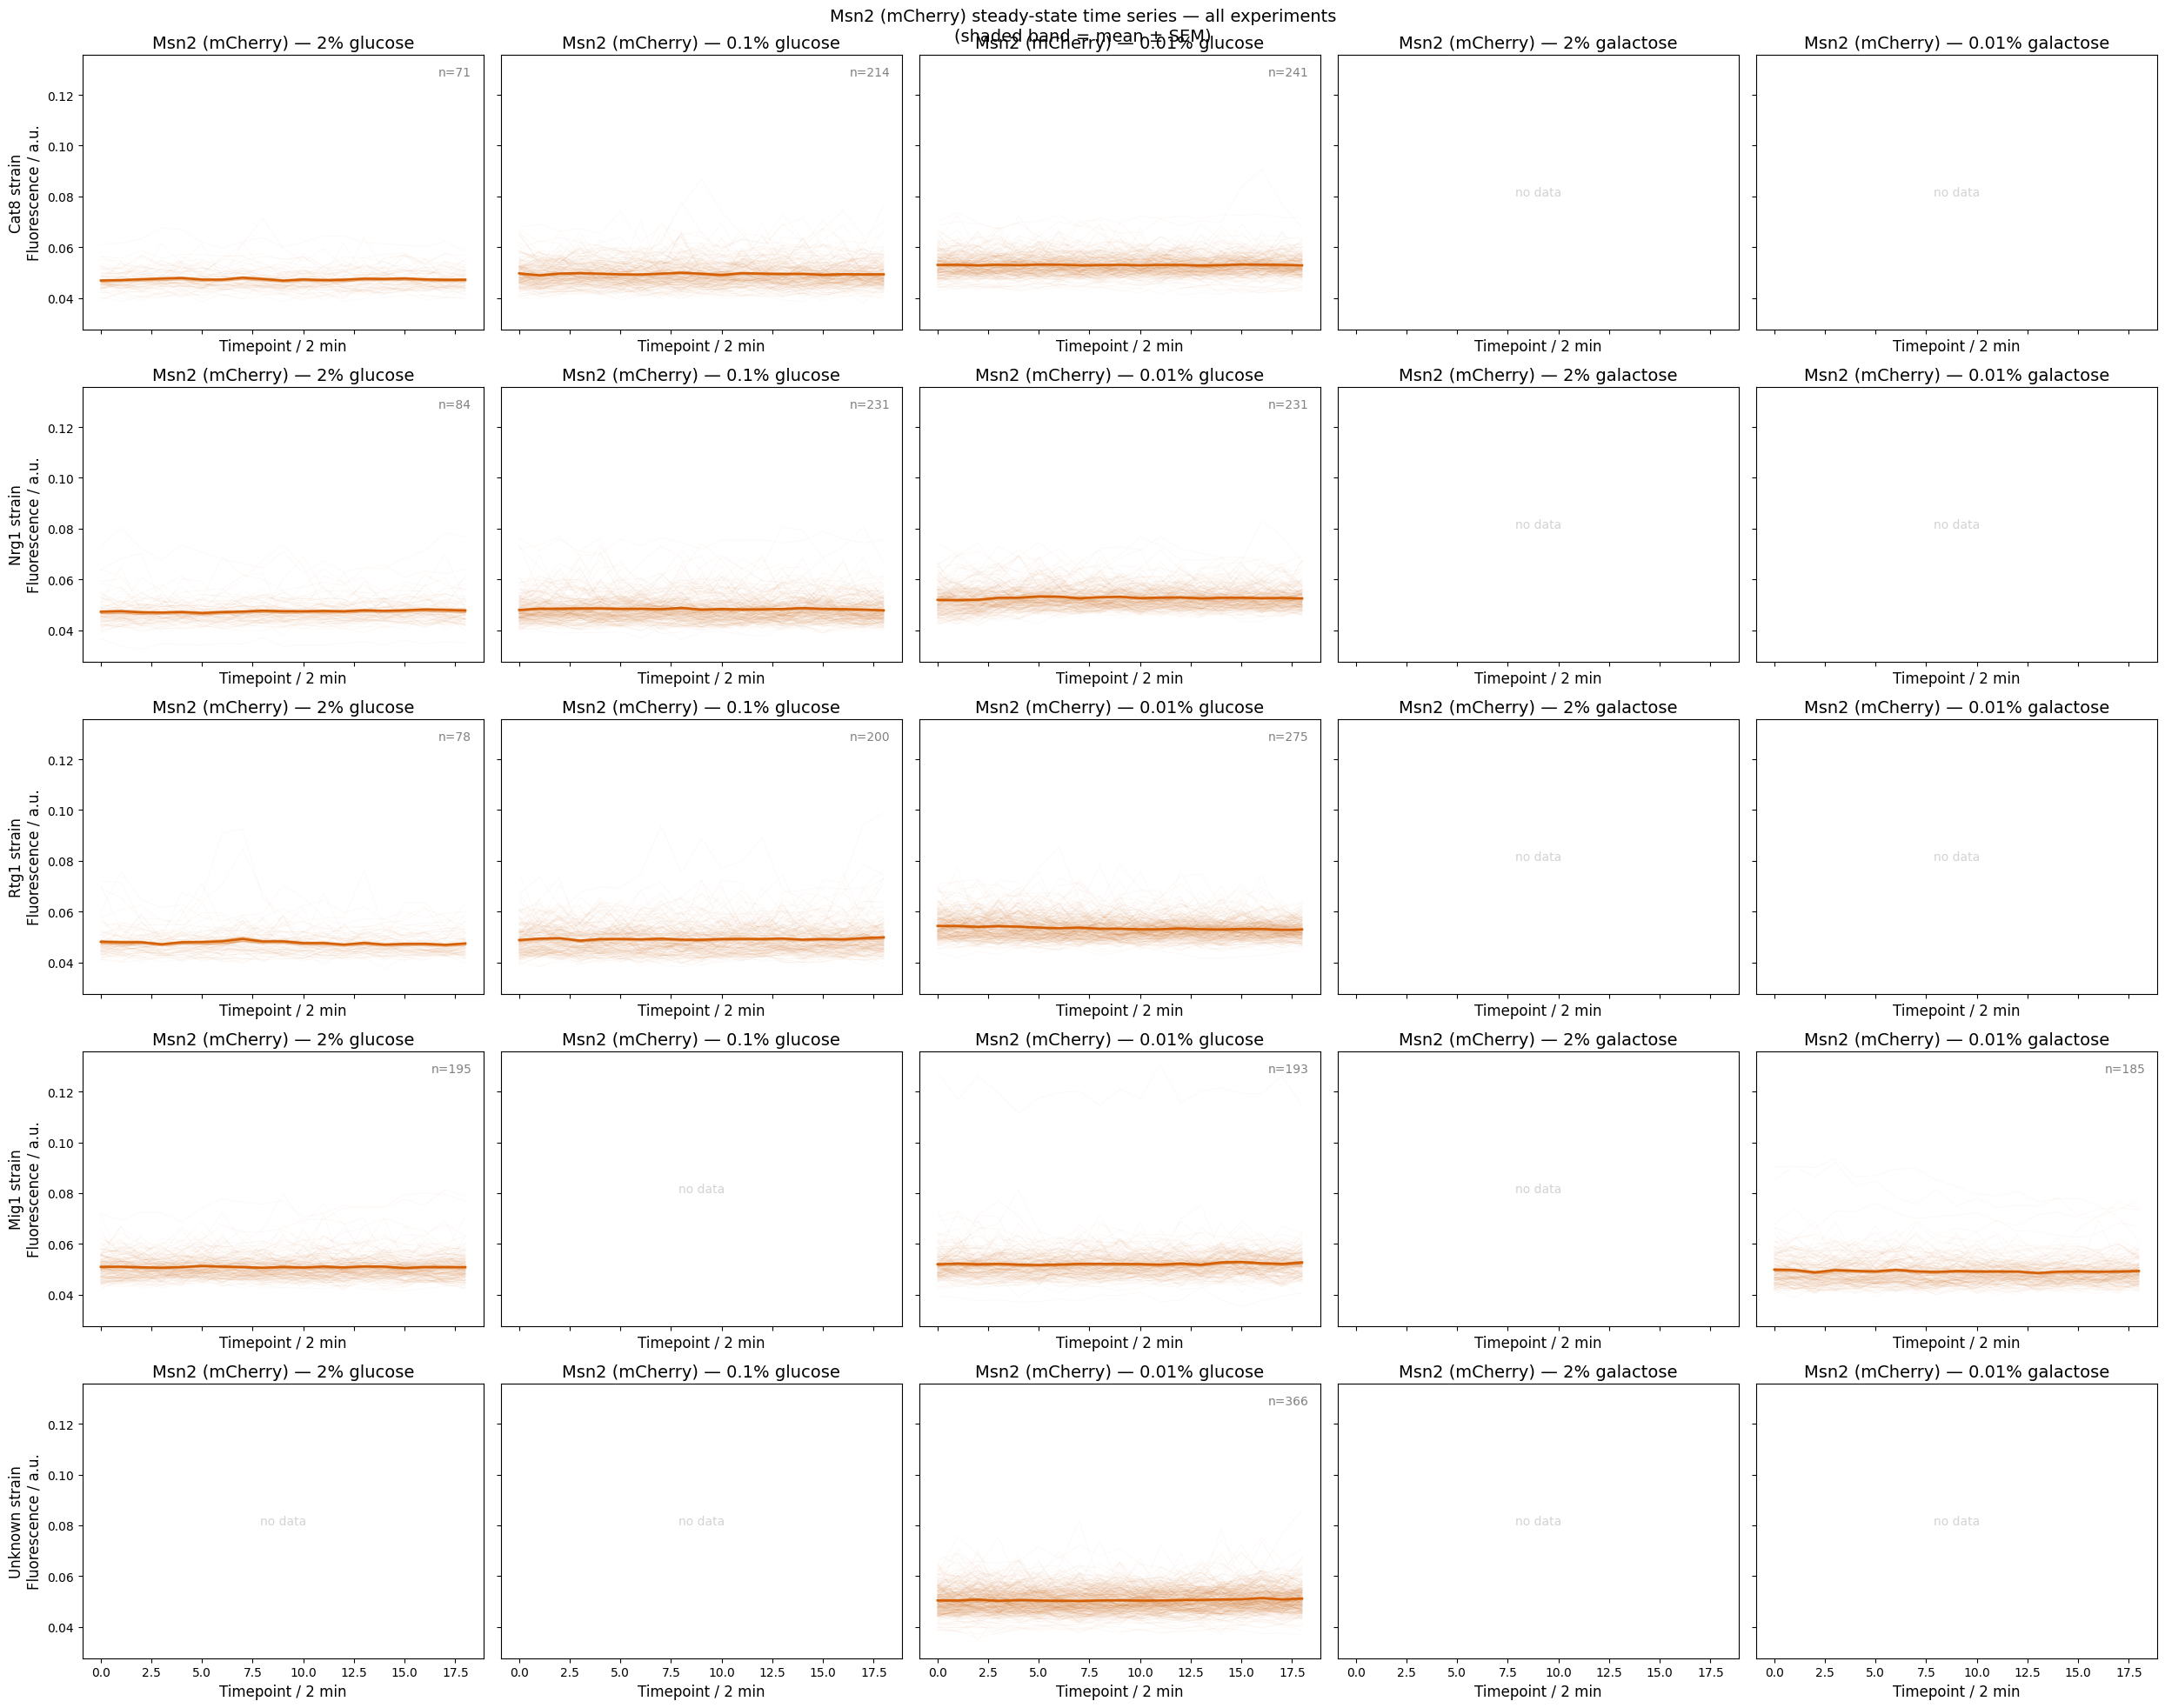

In [4]:
import re as _re
import seaborn as sns

plt.rcParams.update({"font.family": "sans-serif"})
palette  = sns.color_palette("colorblind")
ch_color = palette[3]  # reddish — mCherry

GROUP_TO_TF = {
    "1344": "Cat8", "1344_6": "Cat8",
    "1346": "Nrg1", "1346_4": "Nrg1",
    "1347": "Rtg1",
    "900":  "Mig1",
    "756":  "Unknown", "903": "Unknown",
}

_plot_X, _plot_y, _plot_tf = [], [], []

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    exp_prefix = csv_path.name.split("_")[0]
    if exp_prefix not in EXPERIMENT_LABELS:
        continue
    if "_mCherry_mCherry_" in csv_path.name:
        continue
    label, _ = EXPERIMENT_LABELS[exp_prefix]
    df = pd.read_csv(csv_path)
    time_cols = [c for c in df.columns if c not in META_COLS]
    ts = df[time_cols].values.astype(float)[:, :min_T]

    m = _re.search(r"_group_(.+?)_mCherry_", csv_path.name)
    group_str = m.group(1) if m else "?"
    tf_name = GROUP_TO_TF.get(group_str, f"group_{group_str}")

    _plot_X.append(ts)
    _plot_y.extend([label] * len(ts))
    _plot_tf.extend([tf_name] * len(ts))

_plot_X  = np.vstack(_plot_X)
_plot_y  = np.array(_plot_y)
_plot_tf = np.array(_plot_tf)

tfs_present   = [t for t in ["Cat8", "Nrg1", "Rtg1", "Mig1", "Unknown"] if t in _plot_tf]
conds_present = sorted(set(_plot_y))
t_axis = np.arange(min_T)
n_rows, n_cols = len(tfs_present), len(conds_present)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=True, sharex=True,
)
axes = np.array(axes).reshape(n_rows, n_cols)

for row, tf in enumerate(tfs_present):
    for col, lbl in enumerate(conds_present):
        ax    = axes[row, col]
        mask  = (_plot_tf == tf) & (_plot_y == lbl)
        X_sub = _plot_X[mask]

        if len(X_sub):
            for trace in X_sub:
                ax.plot(t_axis, trace, color=ch_color, alpha=0.05, linewidth=0.5)
            mean = np.nanmean(X_sub, axis=0)
            sem  = np.nanstd(X_sub, axis=0) / np.sqrt(len(X_sub))
            ax.plot(t_axis, mean, color=ch_color, linewidth=1.8)
            ax.fill_between(t_axis, mean - sem, mean + sem, color=ch_color, alpha=0.3)
            ax.text(0.97, 0.96, f"n={mask.sum()}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=10, color="gray")
        else:
            ax.text(0.5, 0.5, "no data", transform=ax.transAxes,
                    ha="center", va="center", fontsize=10, color="lightgray")

        ax.set_title(f"Msn2 (mCherry) — {label_names[lbl]}", fontsize=14)
        ax.set_xlabel("Timepoint / 2 min", fontsize=12)
        if col == 0:
            ax.set_ylabel(f"{tf} strain\nFluorescence / a.u.", fontsize=12)
        ax.tick_params(labelsize=10)

fig.suptitle(
    "Msn2 (mCherry) steady-state time series — all experiments\n"
    "(shaded band = mean ± SEM)",
    fontsize=14,
)
plt.tight_layout()
plt.show()


## 2. Preprocessing: NaN Fill, Balance & Normalize

In [5]:
def fill_nans(X):
    """Interpolate NaNs per row; fallback to column median."""
    X = X.copy()
    for i in range(X.shape[0]):
        row = pd.Series(X[i])
        row = row.interpolate().ffill().bfill()
        X[i] = row.values
    col_medians = np.nanmedian(X, axis=0)
    nan_mask = np.isnan(X)
    X[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])
    return X

def batch_wise_normalize(X):
    """
    Replicate SimCLR batch-wise normalisation:
    z-score per timepoint computed across the whole dataset
    (mean and std over the sample axis, shape → (1, T)).
    """
    m = X.mean(axis=0, keepdims=True)       # (1, T)
    s = X.std(axis=0, keepdims=True) + 1e-8 # (1, T)
    return (X - m) / s

X_clean = fill_nans(X_raw)
print(f"NaN remaining: {np.isnan(X_clean).sum()}")

# Balance to minority class
min_count = min(np.sum(y == lbl) for lbl in label_names)
print(f"Balancing to {min_count} samples per class")

rng = np.random.default_rng(42)
bal_idx = np.concatenate([
    rng.choice(np.where(y == lbl)[0], size=min_count, replace=False)
    for lbl in sorted(label_names)
])
X_bal = X_clean[bal_idx]
y_bal = y[bal_idx]

# Batch-wise normalise — applied to the full balanced dataset
X_norm = batch_wise_normalize(X_bal)
print(f"Balanced & normalised: {X_norm.shape}  |  class counts: {np.bincount(y_bal)}")

# Train / test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)
print(f"Train {X_train.shape[0]}  |  Test {X_test.shape[0]}")

NaN remaining: 0
Balancing to 578 samples per class
Balanced & normalised: (2890, 19)  |  class counts: [578 578 578 578 578]
Train 2312  |  Test 578


## 3. SimCLR Model Registry & Helper Functions

In [6]:
import re

# Known norm method overrides where the filename doesn't contain a keyword
NORM_OVERRIDES = {
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model": "joint",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model": "global",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model": "joint",
}

def parse_arch_from_name(name: str) -> dict:
    """Parse d_model, nhead, num_layers from checkpoint filename."""
    d_model    = int(re.search(r"_D(\d+)", name).group(1))
    nhead      = int(re.search(r"_H(\d+)", name).group(1))
    num_layers = int(re.search(r"_L(\d+)", name).group(1))
    return dict(input_size=1, d_model=d_model, nhead=nhead,
                num_layers=num_layers, dropout=0.01, use_conv1d=False)

def make_short_label(path: Path) -> str:
    """Generate a concise plot label from the checkpoint path."""
    exp    = path.parts[-2]
    stem   = path.stem
    exp_id = re.search(r"IY\d+", exp).group()

    bs = re.search(r"_b(\d+)", stem)
    bs = f"b{bs.group(1)}" if bs else ""

    dm = re.search(r"_D(\d+)", stem)
    dm = f"D{dm.group(1)}" if dm else ""

    if   "batch-wise" in stem:              norm = "batch"
    elif "mixed"      in stem:              norm = "mixed"
    elif stem in NORM_OVERRIDES:            norm = NORM_OVERRIDES[stem]
    else:                                   norm = "inst"

    return f"{exp_id}-{norm} {bs} {dm}".strip()

# Auto-discover all checkpoints across IY017, IY022, IY023
CKPT_DIRS = ["EXP-26-IY017", "EXP-26-IY022", "EXP-26-IY023", "EXP-26-IY024"]
MODEL_REGISTRY = []
for d in CKPT_DIRS:
    for p in sorted((EXP_DIR / d).glob("*.pth")):
        MODEL_REGISTRY.append((p, make_short_label(p)))

print(f"Found {len(MODEL_REGISTRY)} checkpoints:")
for p, lbl in MODEL_REGISTRY:
    arch = parse_arch_from_name(p.name)
    print(f"  [{p.parts[-2]}]  {lbl:<40s}  d_model={arch['d_model']}")

# -----------------------------------------------------------------------

def load_model(checkpoint_path, device):
    """Instantiate with architecture parsed from filename, then load weights."""
    kwargs = parse_arch_from_name(checkpoint_path.name)
    model  = SSL_Transformer(**kwargs)
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    return model

def encode_dataset(model, X_np, device, batch_size=256):
    """Encode (N, T) array → (N, D) embeddings via frozen backbone.encode()."""
    embeddings = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(X_np), batch_size):
            chunk = X_np[start : start + batch_size]
            x = torch.from_numpy(chunk).float().unsqueeze(-1).to(device)  # (B, T, 1)
            h = model.backbone.encode(x)                                   # (B, D)
            embeddings.append(h.cpu().numpy())
    return np.concatenate(embeddings, axis=0)

def run_simclr_svm(model, X_tr, X_te, y_tr, y_te, device):
    """Extract embeddings → StandardScale → SVM (RBF) → (accuracy, y_pred)."""
    Z_tr = encode_dataset(model, X_tr, device)
    Z_te = encode_dataset(model, X_te, device)
    scaler  = StandardScaler()
    Z_tr_sc = scaler.fit_transform(Z_tr)
    Z_te_sc = scaler.transform(Z_te)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
    clf.fit(Z_tr_sc, y_tr)
    y_pred = clf.predict(Z_te_sc)
    return accuracy_score(y_te, y_pred), y_pred

Found 34 checkpoints:
  [EXP-26-IY017]  IY017-inst b100 D128                      d_model=128
  [EXP-26-IY017]  IY017-inst b100 D128                      d_model=128
  [EXP-26-IY017]  IY017-inst b1024 D16                      d_model=16
  [EXP-26-IY017]  IY017-inst b1024 D16                      d_model=16
  [EXP-26-IY017]  IY017-inst b128 D16                       d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16                        d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16                        d_model=16
  [EXP-26-IY017]  IY017-inst b2048 D16                      d_model=16
  [EXP-26-IY017]  IY017-inst b256 D16                       d_model=16
  [EXP-26-IY017]  IY017-inst b32 D128                       d_model=128
  [EXP-26-IY017]  IY017-inst b4096 D16                      d_model=16
  [EXP-26-IY017]  IY017-inst b4096 D16                      d_model=16
  [EXP-26-IY017]  IY017-inst b512 D16                       d_model=16
  [EXP-26-IY017]  IY017-inst b64 D16                

## 4. Run All Models

In [7]:
results = {}  # {label: (accuracy, y_pred)}

for ckpt_path, label in MODEL_REGISTRY:
    print(f"\n{'='*60}")
    print(f"Model: {label}")
    print(f"  {ckpt_path.name}")

    try:
        model = load_model(ckpt_path, DEVICE)
        acc, y_pred = run_simclr_svm(model, X_train, X_test, y_train, y_test, DEVICE)
        results[label] = (acc, y_pred)
        print(f"  Accuracy: {acc:.4f}")
    except Exception as e:
        print(f"  FAILED: {e}")
        results[label] = (np.nan, None)

print("\n\n=== Summary ===")
print(f"Experiments: {sorted(EXPERIMENT_LABELS.keys())}")
print(f"Truncated to {X_train.shape[1]} timepoints (global minimum across all loaded files)")
print()
for label, (acc, _) in results.items():
    print(f"  {label:<35s}  {acc:.4f}" if not np.isnan(acc) else f"  {label:<35s}  FAILED")


Model: IY017-inst b100 D128
  IY017_simCLR_b100_lr0.01_L2_H4_D128_model.pth


  Accuracy: 0.2751

Model: IY017-inst b100 D128
  IY017_simCLR_b100_lr0.01_d0.01_L2_H4_D128_model.pth
  Accuracy: 0.2855

Model: IY017-inst b1024 D16
  IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260219_164413_model.pth
  Accuracy: 0.3062

Model: IY017-inst b1024 D16
  IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260224_061239_model.pth
  Accuracy: 0.2889

Model: IY017-inst b128 D16
  IY017_simCLR_b128_lr0.01_L2_H4_D16_20260217_151037_model.pth
  Accuracy: 0.3287

Model: IY017-inst b16 D16
  IY017_simCLR_b16_lr0.01_L2_H4_D16_model.pth
  Accuracy: 0.2837

Model: IY017-inst b16 D16
  IY017_simCLR_b16_lr0.01_d0.01_L2_H4_D16_model.pth
  Accuracy: 0.2837

Model: IY017-inst b2048 D16
  IY017_simCLR_b2048_lr0.01_L2_H4_D16_20260220_162432_model.pth
  Accuracy: 0.3270

Model: IY017-inst b256 D16
  IY017_simCLR_b256_lr0.01_L2_H4_D16_20260218_154425_model.pth
  Accuracy: 0.2924

Model: IY017-inst b32 D128
  IY017_simCLR_b32_lr0.01_L2_H4_D128_model.pth
  Accuracy: 0.3097

Model: IY017-inst b4096 D16
  IY017_si

## 5. Results Visualisation

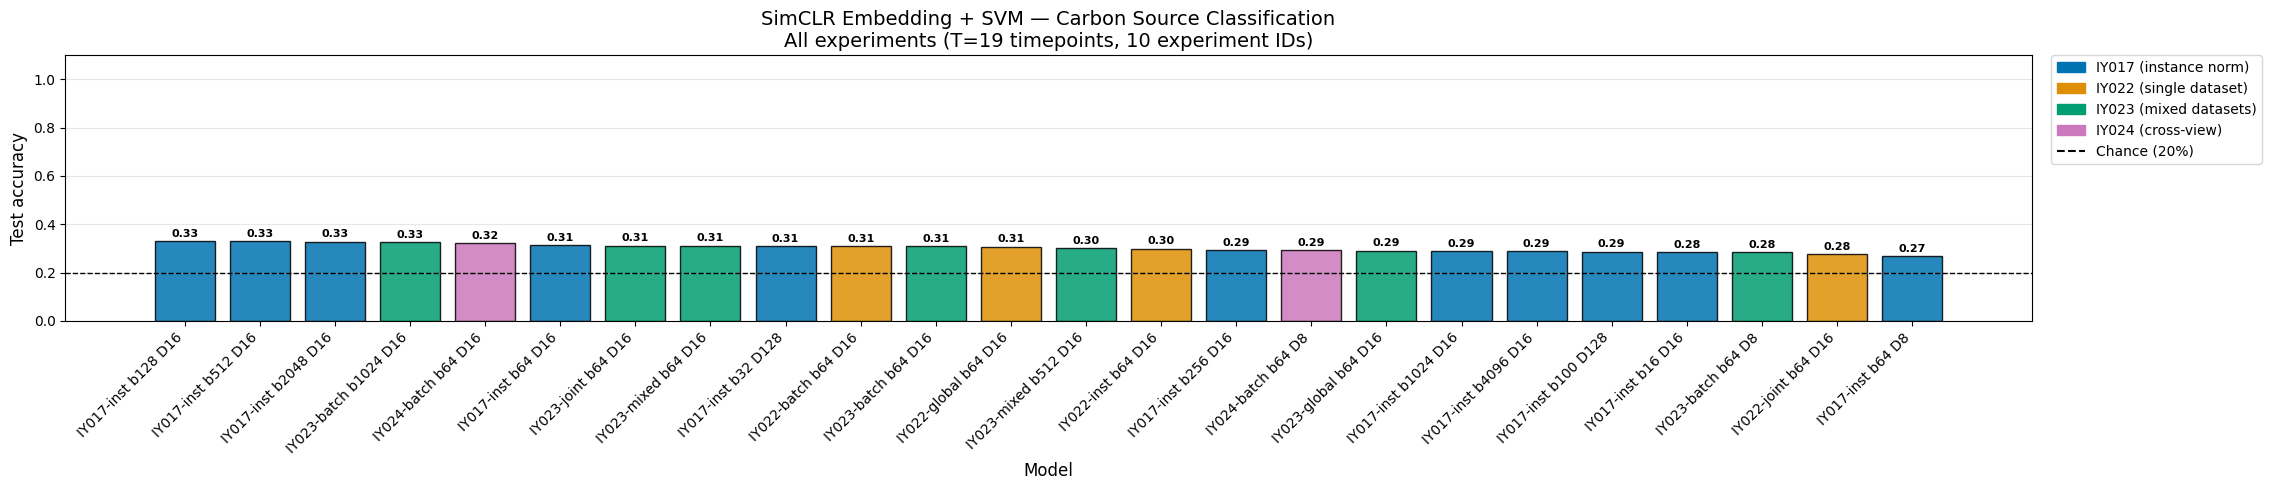

In [8]:
import seaborn as sns
from matplotlib.patches import Patch

plt.rcParams.update({"font.family": "sans-serif"})
palette = sns.color_palette("colorblind")

valid_results = dict(sorted(
    ((k, v) for k, v in results.items() if not np.isnan(v[0])),
    key=lambda item: item[1][0],
    reverse=True,
))
model_labels  = list(valid_results.keys())
accs          = [valid_results[k][0] for k in model_labels]
class_names   = [label_names[i] for i in sorted(label_names)]
chance        = 1 / len(label_names)

color_map = {
    "IY017": palette[0],
    "IY022": palette[1],
    "IY023": palette[2],
    "IY024": palette[4],
}
bar_colors = [color_map.get(next((k for k in color_map if k in lbl), ""), palette[7])
              for lbl in model_labels]

fig, ax = plt.subplots(figsize=(max(12, len(model_labels) * 0.95), 5))
bars = ax.bar(range(len(model_labels)), accs, color=bar_colors, alpha=0.85, edgecolor="black")
ax.axhline(chance, color="black", linestyle="--", linewidth=1.0)
ax.set_xticks(range(len(model_labels)))
ax.set_xticklabels(model_labels, rotation=45, ha="right", fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Test accuracy", fontsize=12)
ax.set_title(
    f"SimCLR Embedding + SVM — Carbon Source Classification\n"
    f"All experiments (T={X_train.shape[1]} timepoints, {len(EXPERIMENT_LABELS)} experiment IDs)",
    fontsize=14,
)
ax.tick_params(axis="y", labelsize=10)
ax.grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{acc:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.legend(handles=[
    Patch(color=palette[0], label="IY017 (instance norm)"),
    Patch(color=palette[1], label="IY022 (single dataset)"),
    Patch(color=palette[2], label="IY023 (mixed datasets)"),
    Patch(color=palette[4], label="IY024 (cross-view)"),
    plt.Line2D([0], [0], color="black", linestyle="--", label=f"Chance ({chance:.0%})"),
], fontsize=10, bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.savefig("IY021_simclr_svm_all_exp_results.png", dpi=150, bbox_inches="tight")
plt.show()


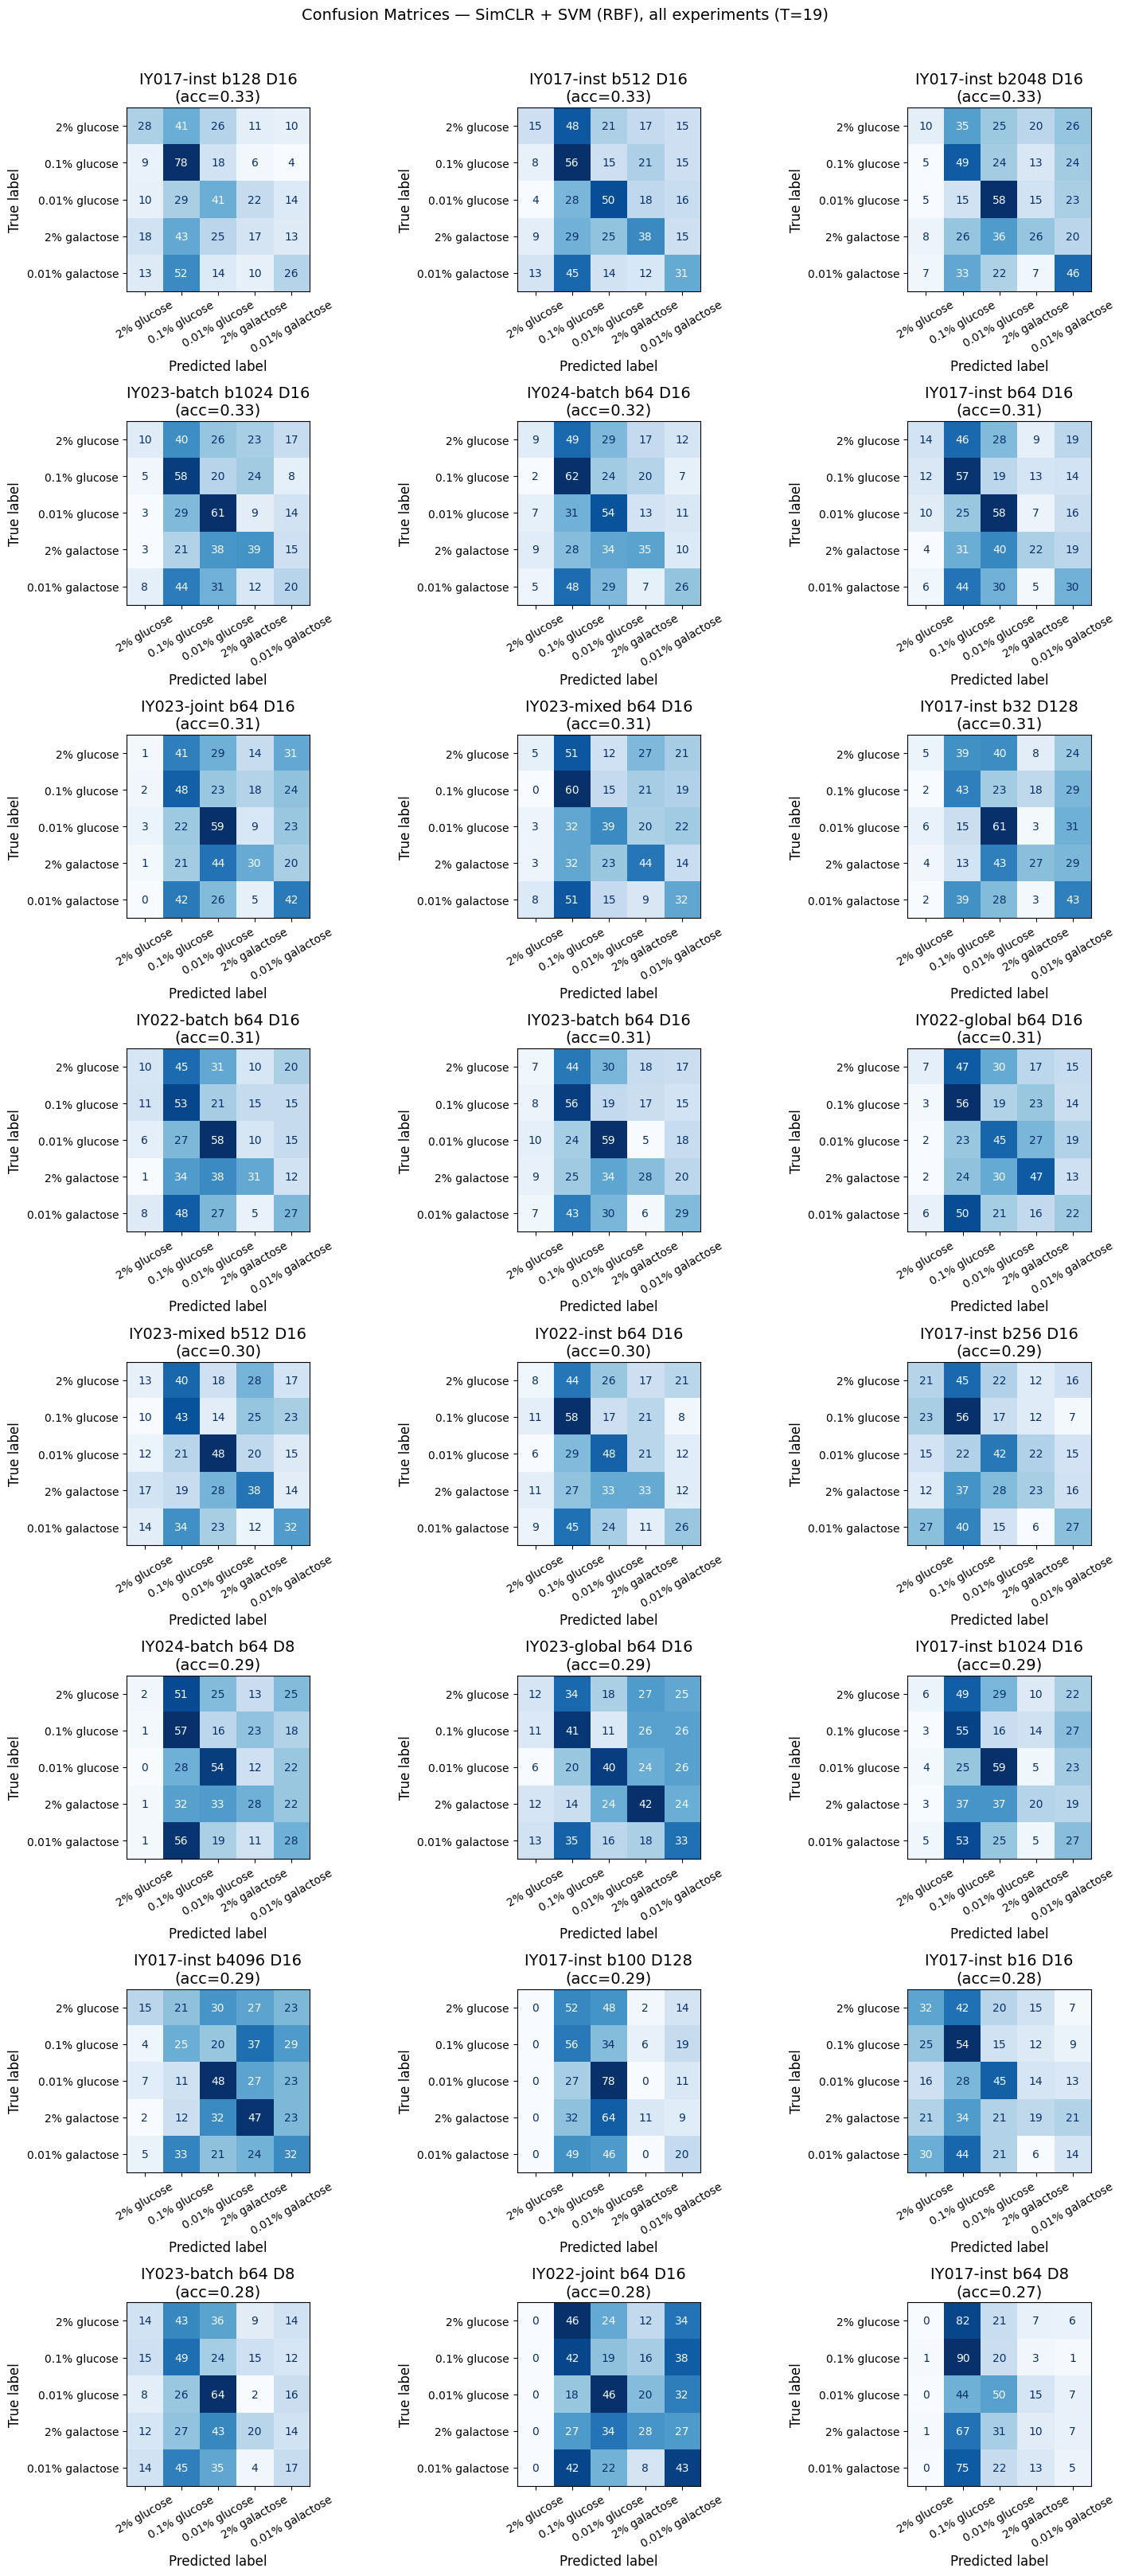

In [9]:
import seaborn as sns

plt.rcParams.update({"font.family": "sans-serif"})

n_valid = len(valid_results)
if n_valid > 0:
    ncols = min(3, n_valid)
    nrows = (n_valid + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten() if n_valid > 1 else [axes]

    for ax, (lbl, (acc, y_pred)) in zip(axes, valid_results.items()):
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred,
            display_labels=class_names,
            ax=ax,
            colorbar=False,
            cmap="Blues",
        )
        ax.set_title(f"{lbl}\n(acc={acc:.2f})", fontsize=14)
        ax.set_xlabel("Predicted label", fontsize=12)
        ax.set_ylabel("True label", fontsize=12)
        ax.tick_params(axis="x", rotation=30, labelsize=10)
        ax.tick_params(axis="y", labelsize=10)

    for ax in axes[n_valid:]:
        ax.set_visible(False)

    plt.suptitle(
        f"Confusion Matrices — SimCLR + SVM (RBF), all experiments (T={X_train.shape[1]})",
        fontsize=14, y=1.01,
    )
    plt.tight_layout()
    plt.savefig("IY021_simclr_all_exp_confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()
